In [13]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

from config import FIGURE_DIR, TABLE_DIR, REPORT_CLASSES
from signal_processing import (
    attach_multilabel_targets,
    bandpower,
    compute_psd,
    highpass_filter,
    load_metadata,
    load_wfdb_record,
    lowpass_filter,
    notch_filter,
    preprocess_record,
    smooth_signal,
)

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

MAX_RECORDS = 0
EXAMPLE_ECG_ID = 189
LEAD_INDEX = 1  # lead II

## Label Distribution

In [14]:
records, labels = attach_multilabel_targets(load_metadata())
if MAX_RECORDS > 0:
    records = records.head(MAX_RECORDS).reset_index(drop=True)
    labels = labels[:MAX_RECORDS]

label_counts = pd.DataFrame({
    "label": REPORT_CLASSES,
    "number_of_samples": labels.sum(axis=0).astype(int),
}).sort_values("number_of_samples", ascending=False)
label_counts.to_csv(TABLE_DIR / "label_distribution.csv", index=False)
label_counts

,label,number_of_samples
3,NORM,9528
2,MI,5486
4,STTC,5250
0,CD,4907
1,HYP,2655


## Dataset-Scale PSD Evidence

In [15]:
metric_rows = []
example_signal = None
example_fs = 100

for row in tqdm(records.itertuples(index=False), total=len(records), desc="Computing PSD", unit="record"):
    try:
        signal, fs = load_wfdb_record(str(row.filename_lr))
        smoothed = smooth_signal(signal)
        notched = notch_filter(smoothed, fs=fs, freq=50.0)
        processed = preprocess_record(signal, fs=fs)
        metric_rows.append({
            "ecg_id": int(row.ecg_id),
            "powerline_before": bandpower(signal[:, LEAD_INDEX], fs, 49.0, min(51.0, fs / 2)),
            "powerline_after": bandpower(notched[:, LEAD_INDEX], fs, 49.0, min(51.0, fs / 2)),
            "baseline_before": bandpower(notched[:, LEAD_INDEX], fs, 0.0, 0.5),
            "baseline_after": bandpower(processed[:, LEAD_INDEX], fs, 0.0, 0.5),
        })
        if int(row.ecg_id) == EXAMPLE_ECG_ID:
            example_signal = signal
            example_fs = fs
    except Exception as exc:
        print(f"Skip ecg_id={row.ecg_id}: {exc}")

metrics = pd.DataFrame(metric_rows)
metrics.to_csv(TABLE_DIR / "preprocessing_psd_metrics.csv", index=False)
metrics.describe()

Computing PSD: 100%|██████████| 21430/21430 [01:25<00:00, 250.66record/s]


,ecg_id,powerline_before,powerline_after,baseline_before,baseline_after
count,21430.000000,2.143000e+04,2.143000e+04,2.143000e+04,2.143000e+04
mean,10883.311293,1.714493e-09,1.231819e-12,3.245942e-03,2.378146e-05
std,6301.234013,7.431853e-10,7.474103e-13,1.569068e-02,8.273267e-05
min,1.000000,2.056959e-10,9.126724e-14,4.889978e-07,7.317058e-08
25%,5422.250000,1.181513e-09,7.008851e-13,8.017291e-05,3.668431e-06
50%,10854.500000,1.590021e-09,1.059683e-12,5.921728e-04,8.160318e-06
75%,16339.750000,2.121584e-09,1.574505e-12,2.084460e-03,1.931497e-05
max,21837.000000,7.438703e-09,9.316721e-12,9.586822e-01,3.528613e-03


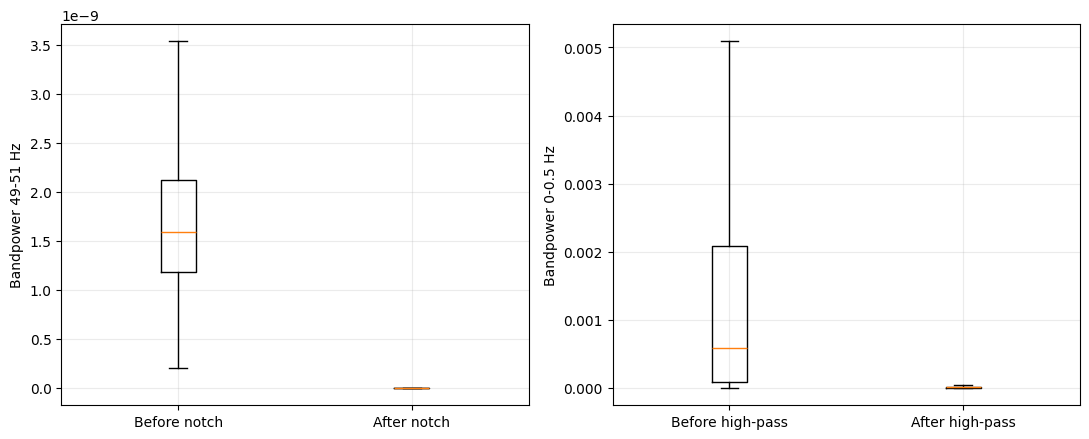

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].boxplot([metrics["powerline_before"], metrics["powerline_after"]], tick_labels=["Before notch", "After notch"], showfliers=False)
axes[0].set_ylabel("Bandpower 49-51 Hz")
axes[0].grid(alpha=0.25)

axes[1].boxplot([metrics["baseline_before"], metrics["baseline_after"]], tick_labels=["Before high-pass", "After high-pass"], showfliers=False)
axes[1].set_ylabel("Bandpower 0-0.5 Hz")
axes[1].grid(alpha=0.25)

fig.tight_layout()
fig.savefig(FIGURE_DIR / "preprocessing_bandpower_boxplots.png", dpi=160, bbox_inches="tight")
plt.show()

## Representative Record: ECG 189, Lead II

In [17]:
if example_signal is None:
    selected = records.loc[records["ecg_id"] == EXAMPLE_ECG_ID].iloc[0]
    example_signal, example_fs = load_wfdb_record(str(selected.filename_lr))

before = example_signal[:, LEAD_INDEX]
smooth = smooth_signal(before)
smooth_notch = notch_filter(smooth, fs=example_fs, freq=50.0)
after = highpass_filter(smooth_notch, fs=example_fs, cutoff=0.5)
time_axis = np.arange(before.size) / example_fs

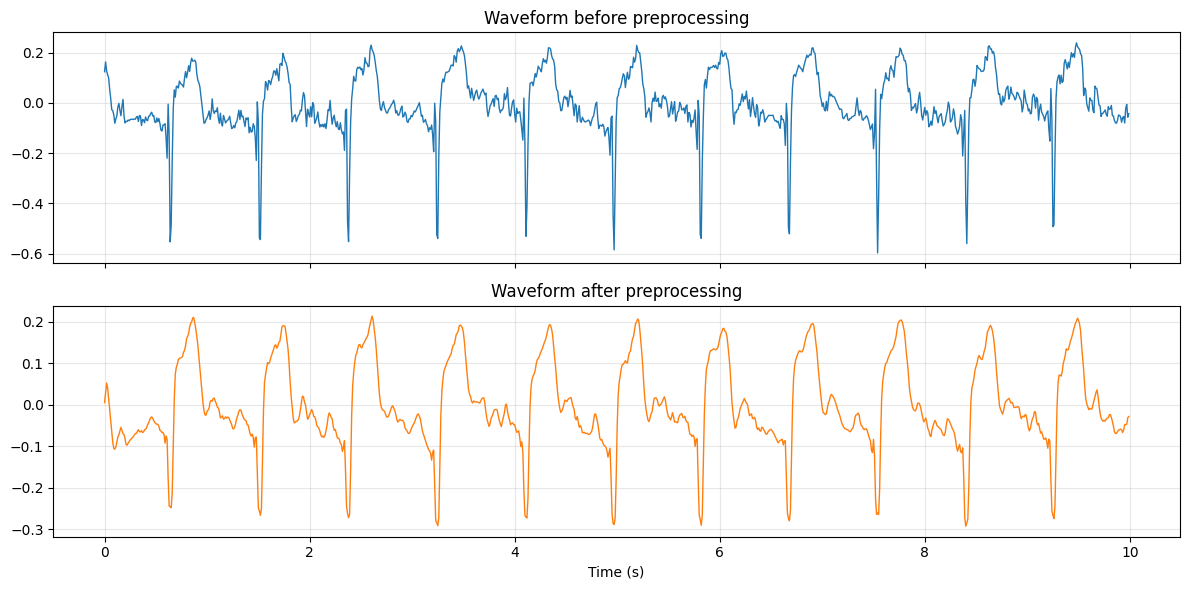

In [18]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(time_axis, before, linewidth=1.0)
axes[0].set_title("Waveform before preprocessing")
axes[0].grid(alpha=0.3)
axes[1].plot(time_axis, after, linewidth=1.0, color="tab:orange")
axes[1].set_title("Waveform after preprocessing")
axes[1].set_xlabel("Time (s)")
axes[1].grid(alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURE_DIR / f"ecg_{EXAMPLE_ECG_ID}_waveform_before_after.png", dpi=150, bbox_inches="tight")
plt.show()

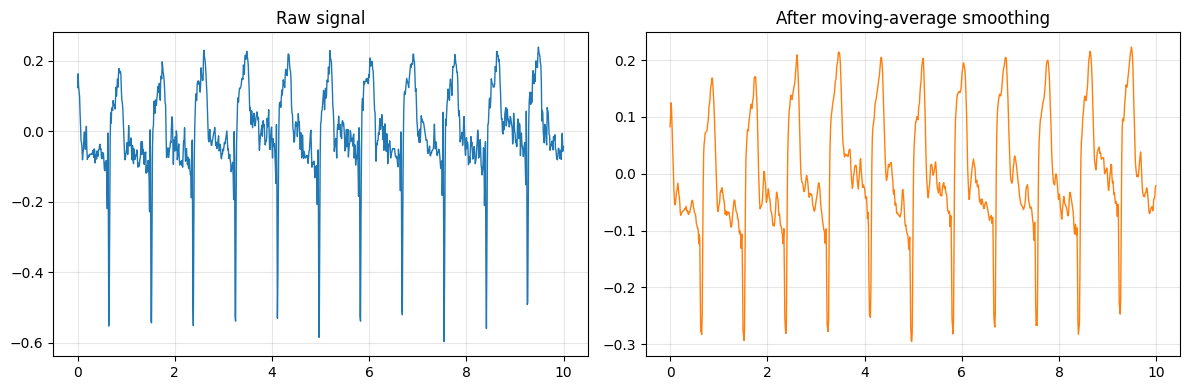

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(time_axis, before, linewidth=1.0)
axes[0].set_title("Raw signal")
axes[0].grid(alpha=0.3)
axes[1].plot(time_axis, smooth, linewidth=1.0, color="tab:orange")
axes[1].set_title("After moving-average smoothing")
axes[1].grid(alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURE_DIR / f"ecg_{EXAMPLE_ECG_ID}_smoothing_step.png", dpi=150, bbox_inches="tight")
plt.show()

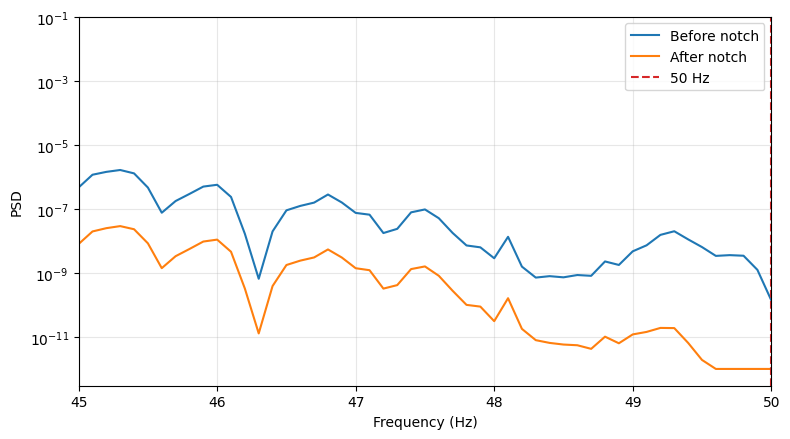

In [20]:
f_before, p_before = compute_psd(before, example_fs)
f_after, p_after = compute_psd(smooth_notch, example_fs)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.semilogy(f_before, np.maximum(p_before, 1e-12), label="Before notch")
ax.semilogy(f_after, np.maximum(p_after, 1e-12), label="After notch")
ax.axvline(50.0, linestyle="--", color="tab:red", label="50 Hz")
ax.set_xlim(45.0, min(55.0, example_fs / 2))
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("PSD")
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / f"ecg_{EXAMPLE_ECG_ID}_notch_psd.png", dpi=150, bbox_inches="tight")
plt.show()

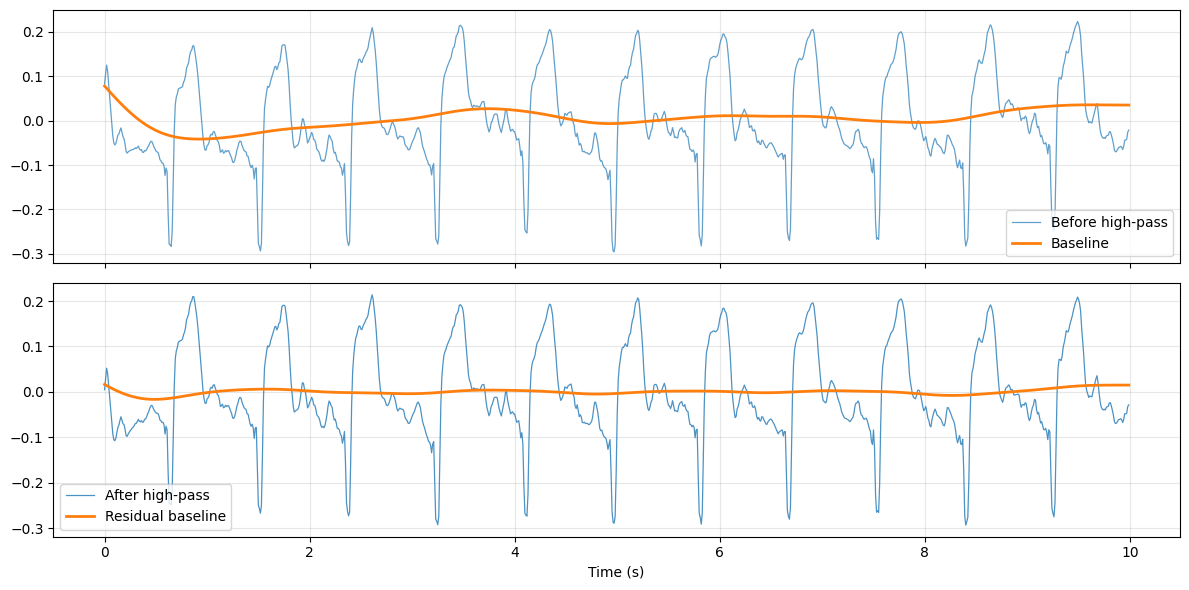

In [21]:
baseline_before = lowpass_filter(smooth_notch, fs=example_fs, cutoff=0.5)
baseline_after = lowpass_filter(after, fs=example_fs, cutoff=0.5)

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(time_axis, smooth_notch, linewidth=0.9, alpha=0.7, label="Before high-pass")
axes[0].plot(time_axis, baseline_before, linewidth=2.0, label="Baseline")
axes[0].grid(alpha=0.3)
axes[0].legend()
axes[1].plot(time_axis, after, linewidth=0.9, alpha=0.8, label="After high-pass")
axes[1].plot(time_axis, baseline_after, linewidth=2.0, label="Residual baseline")
axes[1].set_xlabel("Time (s)")
axes[1].grid(alpha=0.3)
axes[1].legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / f"ecg_{EXAMPLE_ECG_ID}_highpass_baseline.png", dpi=150, bbox_inches="tight")
plt.show()

## Baseline drift theo timestep


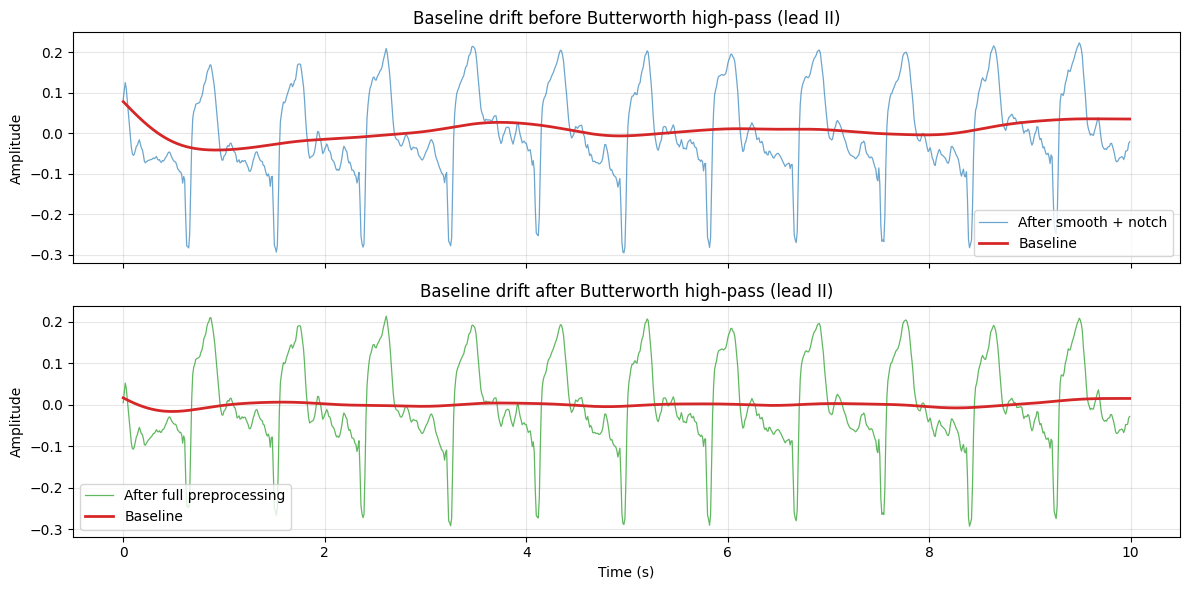

In [22]:
baseline_before = lowpass_filter(smooth_notch, fs=example_fs, cutoff=0.5)
baseline_after = lowpass_filter(after, fs=example_fs, cutoff=0.5)

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(time_axis, smooth_notch, color="tab:blue", linewidth=0.9, alpha=0.65, label="After smooth + notch")
axes[0].plot(time_axis, baseline_before, color="tab:red", linewidth=2.0, label="Baseline")
axes[0].set_title("Baseline drift before Butterworth high-pass (lead II)")
axes[0].set_ylabel("Amplitude")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(time_axis, after, color="tab:green", linewidth=0.9, alpha=0.75, label="After full preprocessing")
axes[1].plot(time_axis, baseline_after, color="tab:red", linewidth=2.0, label="Baseline")
axes[1].set_title("Baseline drift after Butterworth high-pass (lead II)")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Amplitude")
axes[1].grid(alpha=0.3)
axes[1].legend()

fig.tight_layout()
fig.savefig(FIGURE_DIR / f"06_ecg_{EXAMPLE_ECG_ID}_II_baseline_drift_timestep.png", dpi=150, bbox_inches="tight")
plt.show()


## PSD before/after panels


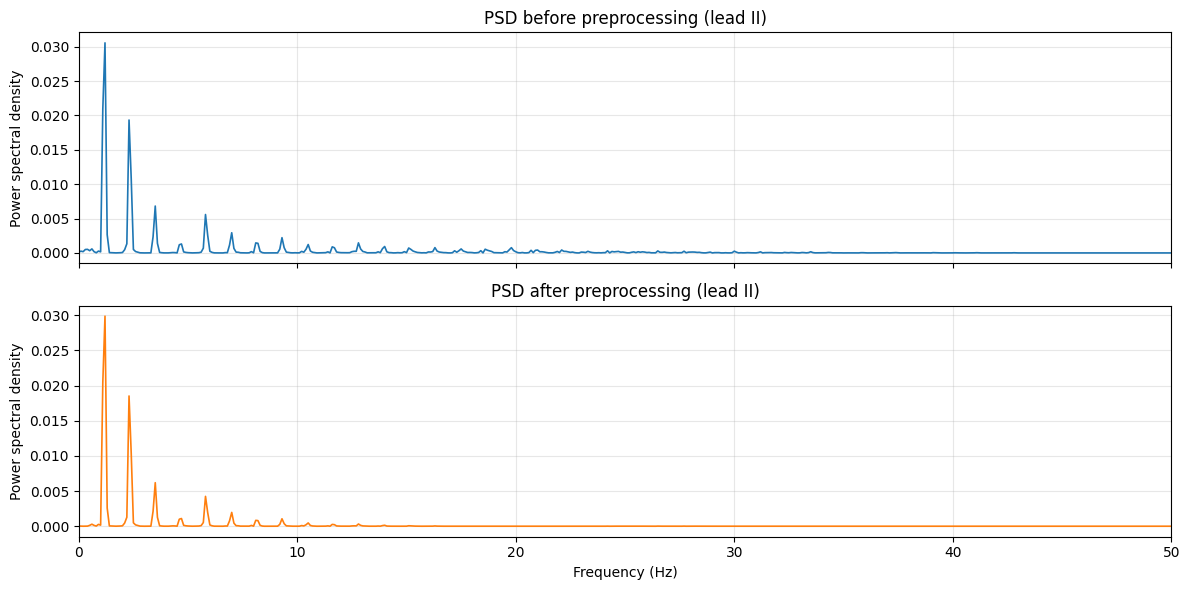

In [23]:
f_before, p_before = compute_psd(before, example_fs)
f_after_full, p_after_full = compute_psd(after, example_fs)

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(f_before, p_before, color="tab:blue", linewidth=1.2)
axes[0].set_xlim(0, example_fs / 2)
axes[0].set_title("PSD before preprocessing (lead II)")
axes[0].set_ylabel("Power spectral density")
axes[0].grid(alpha=0.3)

axes[1].plot(f_after_full, p_after_full, color="tab:orange", linewidth=1.2)
axes[1].set_xlim(0, example_fs / 2)
axes[1].set_title("PSD after preprocessing (lead II)")
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("Power spectral density")
axes[1].grid(alpha=0.3)

fig.tight_layout()
fig.savefig(FIGURE_DIR / f"06_ecg_{EXAMPLE_ECG_ID}_II_psd_before_after_panels.png", dpi=150, bbox_inches="tight")
plt.show()


## Waveform preprocessing summary table


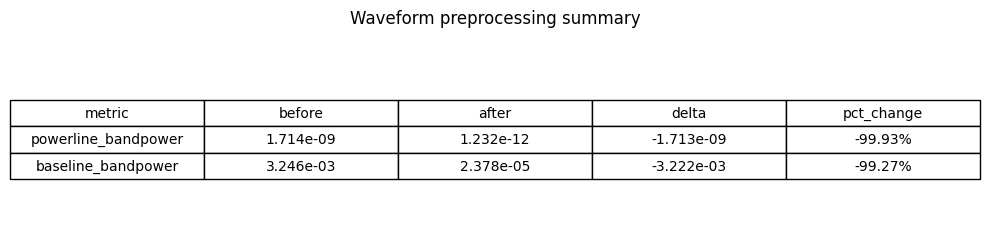

,metric,before,after,delta,pct_change
0,powerline_bandpower,1.714493e-09,1.231819e-12,-1.713261e-09,-99.928153
1,baseline_bandpower,3.245942e-03,2.378146e-05,-3.222161e-03,-99.267348


In [24]:
summary_df = pd.DataFrame([
    {"metric": "powerline_bandpower", "before": float(metrics["powerline_before"].mean()), "after": float(metrics["powerline_after"].mean())},
    {"metric": "baseline_bandpower", "before": float(metrics["baseline_before"].mean()), "after": float(metrics["baseline_after"].mean())},
])
summary_df["delta"] = summary_df["after"] - summary_df["before"]
summary_df["pct_change"] = np.where(summary_df["before"] != 0, summary_df["delta"] / summary_df["before"] * 100.0, np.nan)
summary_df.to_csv(TABLE_DIR / "08_waveform_preprocessing_summary.csv", index=False)

display_df = summary_df.copy()
display_df["before"] = display_df["before"].map(lambda value: f"{value:.3e}")
display_df["after"] = display_df["after"].map(lambda value: f"{value:.3e}")
display_df["delta"] = display_df["delta"].map(lambda value: f"{value:.3e}")
display_df["pct_change"] = display_df["pct_change"].map(lambda value: f"{value:.2f}%")

fig, ax = plt.subplots(figsize=(10, 2.6))
ax.axis("off")
table = ax.table(cellText=display_df.values, colLabels=display_df.columns, cellLoc="center", loc="center")
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.0, 1.6)
ax.set_title("Waveform preprocessing summary", pad=12)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "08_waveform_preprocessing_summary_table.png", dpi=160, bbox_inches="tight")
plt.show()
summary_df
